[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ScriptsRemote/Transcend_SummerSchool/blob/main/Day2_Hydroeconomics_and_Water_Mapping/03_vegetation_and_water_spectral_indices.ipynb)

# Day 2 - Hydroeconomics & Water Mapping
## Session 3: Vegetation and Water Spectral Indices

| | |
|---|---|
| **Fecha / Date** | 2026-10-13 (Tuesday / Martes) |
| **Horario / Time** | 14:00 - 15:30 |
| **Entidad / Entity** | SEI / IMDEA |
| **Instructores / Instructors** | Christhian, Sebastian |

### Contenido / Content

> Vegetation and water spectral indices (NDVI, EVI, SAVI, NDWI, NDMI, NDTI, NDCI): what each measures and when to use it. Index time series for crop phenology, water stress and water quality

### Objetivos de aprendizaje / Learning objectives

- [ ] Write the equation of each index and identify which spectral bands it uses
- [ ] Compute the seven indices on a Sentinel-2 image and compare their spatial patterns
- [ ] Apply the same computation to a one-year image collection with a single function
- [ ] Extract an index time series for a drawn region and read it in terms of crop phenology and water availability

### Datos necesarios / Required data

No local files are needed: the imagery is read from the Earth Engine catalogue
(`COPERNICUS/S2_SR_HARMONIZED`, Sentinel-2 Level-2A surface reflectance).
The Earth Engine account set up in session 2 is required.

---


## 3.1 - Earth Engine and the study area

We repeat the first three steps of session 2: connect to Earth Engine, open an interactive
map, and take the study area from a geometry drawn on that map. Only the sensor changes -
here we work exclusively with Sentinel-2, because its 10-20 m pixel and 5-day revisit are
adequate for field-scale monitoring.


In [ ]:
# ---------------------------------------------------------------------------
# Libraries (uncomment the pip line on a fresh runtime, e.g. Google Colab)
# ---------------------------------------------------------------------------
#%pip install -q earthengine-api geemap

import ee
import geemap

print("ee", ee.__version__, "| geemap", geemap.__version__)

In [ ]:
# ---------------------------------------------------------------------------
# Authenticate and initialise Earth Engine
# ---------------------------------------------------------------------------
# >>> REPLACE with your own Cloud project id <<<
EE_PROJECT = "ee-christhianscunha"

ee.Authenticate()
ee.Initialize(project=EE_PROJECT)

print("Earth Engine connected - project:", EE_PROJECT)

### Select the study area

Use the **marker** or the **polygon** tool on the left toolbar to place your study area.
Indices are computed per pixel, so a point is enough to locate the scene; the analysis
window is built around it in the next cell.

If nothing is drawn the notebook falls back to the point used in session 2, on the Bolivian
altiplano, so it remains runnable end to end.


In [ ]:
# ---------------------------------------------------------------------------
# Interactive map - draw your study area here
# ---------------------------------------------------------------------------
DEFAULT_LON, DEFAULT_LAT = -68.7849, -16.5523   # same point used in session 2

Map = geemap.Map(center=[DEFAULT_LAT, DEFAULT_LON], zoom=12)
Map.add_basemap("SATELLITE")

Map

In [ ]:
# ---------------------------------------------------------------------------
# Study area: the drawn geometry, plus a 5 km window used to clip the displays
# ---------------------------------------------------------------------------
roi = Map.user_roi if Map.user_roi is not None else ee.Geometry.Point([DEFAULT_LON, DEFAULT_LAT])

CENTER_LON, CENTER_LAT = roi.centroid(maxError=1).coordinates().getInfo()
AOI = roi.buffer(5000).bounds()

Map.addLayer(AOI, {"color": "yellow"}, "AOI (5 km window)")
Map.centerObject(AOI, 12)

print("Centre  : lon = {:.4f}, lat = {:.4f}".format(CENTER_LON, CENTER_LAT))
print("AOI area: {:.1f} km2".format(AOI.area(maxError=1).divide(1e6).getInfo()))

## 3.2 - Sentinel-2 collection and cloud masking

Two parameters are fixed here and reused for the rest of the notebook:

- **Period**: one year, so the time series in section 3.6 covers a complete growing cycle.
- **Maximum scene cloud cover**: 35%. This is a *scene-level* filter on the metadata field
  `CLOUDY_PIXEL_PERCENTAGE`; it discards images that are mostly cloud. It does not remove
  the remaining clouds inside the accepted scenes, which is the job of the per-pixel mask.

The per-pixel mask uses the **SCL** band (Scene Classification Layer), produced by Sen2Cor,
which assigns a class to every pixel. We discard saturated pixels (1), cloud shadow (3),
cloud at medium and high probability (8, 9), thin cirrus (10) and snow/ice (11), and keep
the rest. Masked pixels are not set to zero: they are removed from the computation, so a
mean over a region ignores them rather than biasing it downwards.

Reflectance is stored as an integer and rescaled by `0.0001`. Indices are ratios, so the
scaling cancels out in the normalised-difference forms - but not in EVI, whose coefficients
assume reflectance in the 0-1 range. Rescaling before computing any index avoids this
inconsistency.


In [ ]:
# ---------------------------------------------------------------------------
# Sentinel-2 Level-2A: filter, mask clouds, rescale to reflectance
# ---------------------------------------------------------------------------
START = "2025-09-01"   # one year of data
END   = "2026-09-01"
CLOUD_MAX = 35         # maximum scene cloud cover, in percent

BANDS = ["B2", "B3", "B4", "B5", "B8", "B11", "B12"]   # blue, green, red, red-edge 1, NIR, SWIR1, SWIR2

def mask_s2(image):
    # SCL classes to discard: 1 saturated, 3 shadow, 8-9 cloud, 10 cirrus, 11 snow
    scl = image.select("SCL")
    clear = (scl.neq(1).And(scl.neq(3)).And(scl.neq(8))
                .And(scl.neq(9)).And(scl.neq(10)).And(scl.neq(11)))
    optical = image.select(BANDS).multiply(0.0001)      # to reflectance 0-1
    return ee.Image(optical.updateMask(clear)
                           .copyProperties(image, ["system:time_start",
                                                   "CLOUDY_PIXEL_PERCENTAGE"]))

s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(roi)
        .filterDate(START, END)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", CLOUD_MAX))
        .map(mask_s2))

print("Period          :", START, "to", END)
print("Cloud filter    : <", CLOUD_MAX, "%")
print("Images retained :", s2.size().getInfo())

In [ ]:
# ---------------------------------------------------------------------------
# Reference image: the least cloudy scene of the period
# ---------------------------------------------------------------------------
image = ee.Image(s2.sort("CLOUDY_PIXEL_PERCENTAGE").first()).clip(AOI)

print("Date        :", ee.Date(image.get("system:time_start")).format("YYYY-MM-dd").getInfo())
print("Cloud cover :", round(image.get("CLOUDY_PIXEL_PERCENTAGE").getInfo(), 1), "%")

---

## 3.3 - The indices

A spectral index is an arithmetic combination of bands chosen so that the property of
interest varies more than the effects that disturb it. Most of the indices in this session
have the **normalised difference** form:

$$ND = \frac{\rho_A - \rho_B}{\rho_A + \rho_B}$$

where $\rho$ is surface reflectance in bands $A$ and $B$. This form is bounded between
-1 and +1 and cancels *multiplicative* effects that scale both bands equally, such as
differences in illumination and topographic shading. It does not cancel *additive* effects
such as residual atmospheric path radiance, nor the contribution of the background (soil)
seen between plants.

Below, each index is defined with its equation, the Sentinel-2 bands it uses, the range of
values normally observed, and its main limitation.

---

### NDVI - Normalized Difference Vegetation Index

$$\text{NDVI} = \frac{\rho_{NIR} - \rho_{RED}}{\rho_{NIR} + \rho_{RED}}
= \frac{B8 - B4}{B8 + B4}$$

Uses the contrast between chlorophyll absorption in the red and the high reflectance of the
leaf mesophyll in the near infrared. Values below 0 occur over water, around 0.1-0.2 over
bare soil, and between 0.5 and 0.9 over closed canopies.

*Limitations.* NDVI saturates when the leaf area index exceeds approximately 3: further
increases in biomass produce little change in the index. In sparse canopies the reflectance
of the soil between plants contributes to both bands and shifts the value.

Rouse et al. (1973).

<img src="https://www.auravant.com/wp-content/uploads/2021/07/NDVI-values-by-crop-condition.jpeg
" width="500"> <img src="https://ece.montana.edu/seniordesign/archive/SP15/OpticalWeedMapping/uploads/4/9/2/7/49273335/1429843234.png
" width="300">

Fig 1- Index NDVI Rouse et al. (1973).

---

### EVI - Enhanced Vegetation Index

$$\text{EVI} = G \cdot \frac{\rho_{NIR} - \rho_{RED}}
{\rho_{NIR} + C_1 \rho_{RED} - C_2 \rho_{BLUE} + L}$$

with $G = 2.5$, $C_1 = 6$, $C_2 = 7.5$, $L = 1$, which for Sentinel-2 gives:

$$\text{EVI} = 2.5 \cdot \frac{B8 - B4}{B8 + 6 \cdot B4 - 7.5 \cdot B2 + 1}$$

The blue term corrects for aerosol scattering, which affects the red band more than the near
infrared; $L$ adjusts for the soil background. EVI responds to changes in dense canopies
where NDVI has already saturated.

*Limitations.* It depends on the blue band, which carries the largest atmospheric residual,
so it is more sensitive to imperfect atmospheric correction. The coefficients assume
reflectance in the 0-1 range.

Huete et al. (2002).

<img src="https://www.researchgate.net/publication/343758033/figure/fig4/AS:960336773533696@1605973537081/Seasonal-dynamics-of-the-Enhanced-Vegetation-Index-EVI-and-of-Ecosystem-Functional.png
" width="500"> 

Fig 2 - EVI example

---

### SAVI - Soil-Adjusted Vegetation Index

$$\text{SAVI} = \frac{\rho_{NIR} - \rho_{RED}}{\rho_{NIR} + \rho_{RED} + L}
\cdot (1 + L), \qquad L = 0.5$$

The same bands as NDVI with a soil-adjustment factor $L$ in the denominator. $L$ should
approach 0 for dense canopies and 1 for very sparse cover; 0.5 is the usual compromise and
the value used here. The $(1+L)$ factor keeps the range comparable to NDVI.

*Limitations.* $L$ is fixed a priori and does not adapt to the actual canopy density, so the
correction is only approximate. For sparse and semi-arid cover SAVI usually differs from
NDVI more than for closed canopies.

Huete (1988).

---

### NDWI - Normalized Difference Water Index (McFeeters)

$$\text{NDWI} = \frac{\rho_{GREEN} - \rho_{NIR}}{\rho_{GREEN} + \rho_{NIR}}
= \frac{B3 - B8}{B3 + B8}$$

Designed to delineate **open water bodies**. Water reflects moderately in the green and
absorbs almost completely in the near infrared, so it gives positive values, while
vegetation and soil give negative ones. A threshold of 0 is commonly used to separate water
from land, although the optimum value depends on the scene.

*Limitations.* Built-up surfaces also produce positive values and are frequently confused
with water. Using the SWIR instead of the NIR (MNDWI, Xu 2006:
$(B3 - B11)/(B3 + B11)$) reduces this confusion.

McFeeters (1996).

<style>
img[alt="image-2.png"] { width: 600px; }
</style>

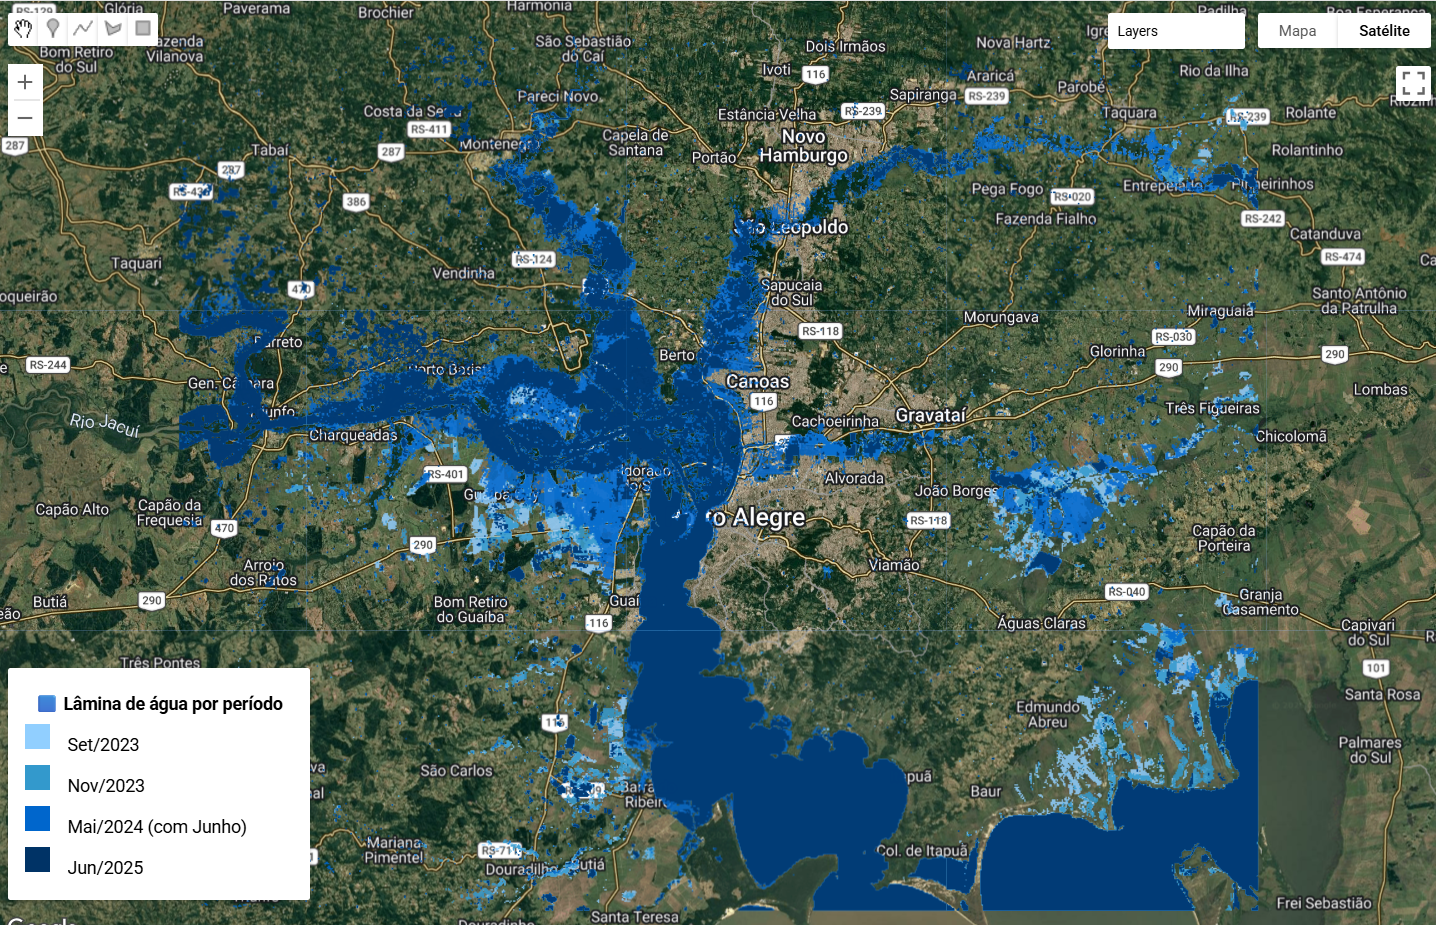

Fig 3 - Floodind in Porto Alegre, 2024, Brazil. [WebApp](https://ee-scriptsambgeo.projects.earthengine.app/view/floodpoaseries)


---

### NDMI - Normalized Difference Moisture Index

$$\text{NDMI} = \frac{\rho_{NIR} - \rho_{SWIR1}}{\rho_{NIR} + \rho_{SWIR1}}
= \frac{B8 - B11}{B8 + B11}$$

Uses the absorption of liquid water around 1.6 um: as the water content of the leaf falls,
SWIR reflectance rises and the index decreases. It tracks **canopy water content** rather
than the amount of green biomass, and it responds to water stress earlier than NDVI, because
the canopy loses water before it loses greenness.

*Limitations.* The signal mixes leaf water content with canopy structure and, in sparse
cover, with soil moisture. It should be interpreted as a relative indicator over time for
the same target, not as an absolute measurement of water content.

Gao (1996).


> **A note on naming.** The index proposed by Gao (1996) was also called NDWI, and has the
> same formula as NDMI above. Two different indices therefore circulate in the literature
> under the name NDWI: McFeeters' (green-NIR, for open water) and Gao's (NIR-SWIR, for
> vegetation water content). Always check which bands are being used.

---

### NDTI - Normalized Difference Turbidity Index

$$\text{NDTI} = \frac{\rho_{RED} - \rho_{GREEN}}{\rho_{RED} + \rho_{GREEN}}
= \frac{B4 - B3}{B4 + B3}$$

Suspended sediment raises the reflectance of water across the whole visible range, but it
raises the red more than the green: clear water absorbs strongly in the red, whereas mineral
particles scatter there. The index therefore increases with **turbidity** and with the
concentration of total suspended solids. Clear water gives negative values and turbid water
positive ones; the relationship with a concentration measured in mg/l is empirical and has to
be calibrated locally.

*Limitations.* It is only meaningful over pixels that are already known to be water, so it
must be applied inside a water mask - NDWI or MNDWI first, NDTI afterwards. Sun glint,
adjacency effects near the shore, bottom reflectance in shallow water and dense algal blooms
all raise the red signal and are read as turbidity.

Lacaux et al. (2007).

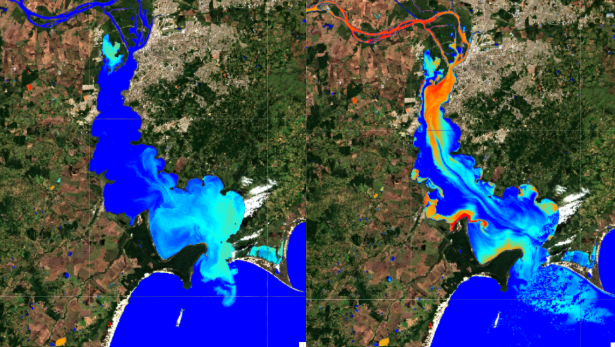

Fig 3 - Rive Guaiba Brazil, NDTI after Rain.

---

### NDCI - Normalized Difference Chlorophyll Index

$$\text{NDCI} = \frac{\rho_{RE1} - \rho_{RED}}{\rho_{RE1} + \rho_{RED}}
= \frac{B5 - B4}{B5 + B4}$$

Built for **chlorophyll-a in inland and coastal waters**. Phytoplankton absorbs in the red
around 665 nm and produces a reflectance peak near 700 nm; B5 (705 nm, the first red-edge
band) sits on that peak while B4 (665 nm) sits in the absorption trough, so the difference
between them grows with the chlorophyll concentration. It is one of the few indices that
Sentinel-2 can compute and Landsat cannot, because Landsat has no red-edge band.

*Limitations.* The same precondition as NDTI: water pixels only. Strong turbidity raises both
bands and weakens the signal, which is why NDCI and NDTI are read together. The conversion to
mg/m3 of chlorophyll-a is empirical and site-specific, and the 20 m pixel of B5 restricts the
index to water bodies at least a few hundred metres across.

Mishra & Mishra (2012).

<style>
img[alt="image-3.png"] { width: 400px; }
</style>

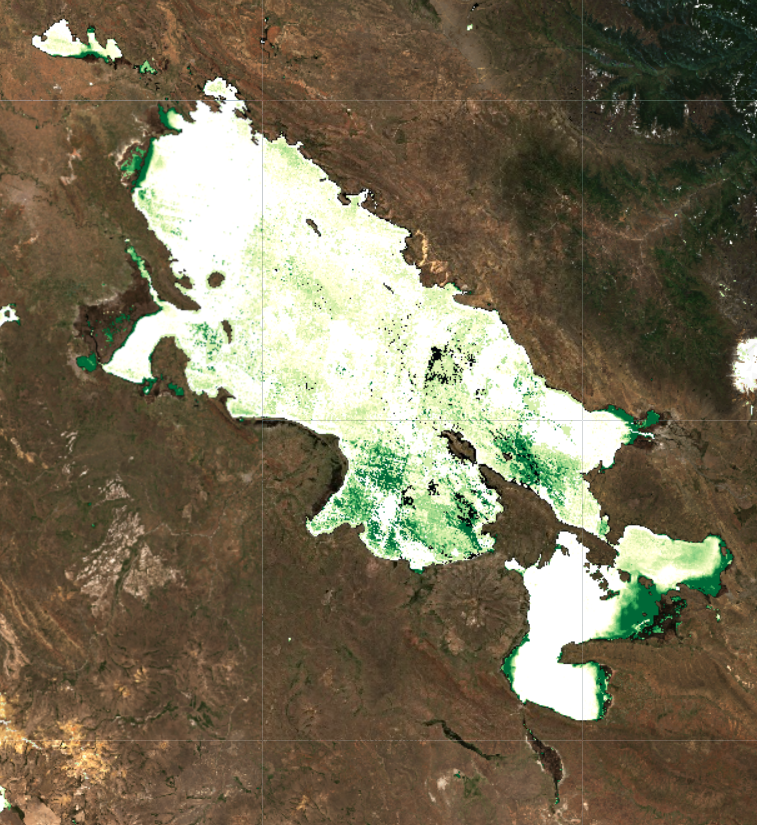

Fig 4 - NDVI in Lake Titicaca - Acess [code](https://code.earthengine.google.com/60bc96d560c6d837fa6871bb96943d49)

---

### Summary

| Index | Bands (S2) | Measures | Typical range |
|---|---|---|---|
| NDVI | B8, B4 | green biomass / vigour | -0.1 to 0.9 |
| EVI | B8, B4, B2 | green biomass, dense canopies | 0 to 1 |
| SAVI | B8, B4 | biomass with soil correction | -0.1 to 0.9 |
| NDWI | B3, B8 | open water | -1 to 1, water > 0 |
| NDMI | B8, B11 | canopy water content | -0.5 to 0.5 |
| NDTI | B4, B3 | turbidity / suspended solids | -0.4 to 0.4, water only |
| NDCI | B5, B4 | chlorophyll-a in water | -0.2 to 0.5, water only |


---

## 3.4 - One index at a time on the reference image

We compute the indices one by one on the least cloudy image and add each result to the same
map, `Map_idx`. The map is displayed again at the end of every cell, so the new layer
appears immediately below the code that produced it; use the layer control to switch
between them.

The three vegetation indices share the same colour scale, which is what makes them
comparable: any difference on screen comes from the index, not from the display.

NDTI and NDCI come last, and inside a water mask built from NDWI: outside water their
values are arithmetically defined but physically meaningless, and displaying them over
land invites exactly the misreading this session is trying to avoid.


In [ ]:
# ---------------------------------------------------------------------------
# NDVI = (B8 - B4) / (B8 + B4)
# ---------------------------------------------------------------------------
# normalizedDifference() implements (first - second) / (first + second).
ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")

# Shared scale for the three vegetation indices
vis_veg = {"min": -0.2, "max": 0.8,
           "palette": ["#f2efe4", "#cfe0ac", "#8fbc6a", "#3f8d47", "#12482a"]}

Map_idx = geemap.Map(center=[CENTER_LAT, CENTER_LON], zoom=13)
Map_idx.addLayer(image, {"bands": ["B4", "B3", "B2"], "min": 0, "max": 0.3}, "True colour")
Map_idx.addLayer(ndvi, vis_veg, "NDVI")

Map_idx

In [ ]:
# ---------------------------------------------------------------------------
# EVI = 2.5 * (B8 - B4) / (B8 + 6*B4 - 7.5*B2 + 1)
# ---------------------------------------------------------------------------
# expression() is used when the formula is not a simple normalised difference.
evi = image.expression(
    "2.5 * (NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1)",
    {"NIR": image.select("B8"), "RED": image.select("B4"), "BLUE": image.select("B2")}
).rename("EVI")

Map_idx.addLayer(evi, vis_veg, "EVI")

# Compare with NDVI over the densest vegetation: EVI keeps varying where NDVI flattens.
Map_idx

In [ ]:
# ---------------------------------------------------------------------------
# SAVI = 1.5 * (B8 - B4) / (B8 + B4 + 0.5)      [ (1+L) * ... with L = 0.5 ]
# ---------------------------------------------------------------------------
savi = image.expression(
    "1.5 * (NIR - RED) / (NIR + RED + 0.5)",
    {"NIR": image.select("B8"), "RED": image.select("B4")}
).rename("SAVI")

Map_idx.addLayer(savi, vis_veg, "SAVI")

# The difference from NDVI is largest over sparse cover, where the soil contributes most.
Map_idx

In [ ]:
# ---------------------------------------------------------------------------
# NDWI = (B3 - B8) / (B3 + B8)
# ---------------------------------------------------------------------------
ndwi = image.normalizedDifference(["B3", "B8"]).rename("NDWI")

vis_water = {"min": -0.5, "max": 0.5,
             "palette": ["#eae4d6", "#b9d3e4", "#5f9fcb", "#1f6aa5", "#08355e"]}

Map_idx.addLayer(ndwi, vis_water, "NDWI")

# Add the water mask obtained with the usual threshold, to be inspected critically
Map_idx.addLayer(ndwi.updateMask(ndwi.gt(0)), {"palette": ["#1f6aa5"]}, "NDWI > 0 (water)")

Map_idx

In [ ]:
# ---------------------------------------------------------------------------
# NDMI = (B8 - B11) / (B8 + B11)
# ---------------------------------------------------------------------------
ndmi = image.normalizedDifference(["B8", "B11"]).rename("NDMI")

# Diverging scale: brown = dry, neutral = intermediate, blue = high water content
vis_ndmi = {"min": -0.5, "max": 0.5,
            "palette": ["#8c5a2b", "#c9a97a", "#efeeec", "#7fb0d0", "#14507d"]}

Map_idx.addLayer(ndmi, vis_ndmi, "NDMI")

Map_idx

In [ ]:
# ---------------------------------------------------------------------------
# NDTI = (B4 - B3) / (B4 + B3)        [water pixels only]
# ---------------------------------------------------------------------------
# Turbidity is defined only over water, so we reuse the NDWI threshold of the
# previous cell as a mask and compute the index inside it.
water_mask = ndwi.gt(0)

ndti = image.normalizedDifference(["B4", "B3"]).rename("NDTI").updateMask(water_mask)

# Sequential scale: blue = clear water, ochre = turbid water
vis_ndti = {"min": -0.3, "max": 0.3,
            "palette": ["#0b3d62", "#3f7fa6", "#9dbfc9", "#d9c08a", "#a9782f"]}

Map_idx.addLayer(ndti, vis_ndti, "NDTI (water only)")

Map_idx

In [ ]:
# ---------------------------------------------------------------------------
# NDCI = (B5 - B4) / (B5 + B4)        [water pixels only]
# ---------------------------------------------------------------------------
# B5 is the first red-edge band (705 nm, 20 m), the one Landsat does not have.
ndci = image.normalizedDifference(["B5", "B4"]).rename("NDCI").updateMask(water_mask)

# Sequential scale: dark = oligotrophic, yellow-green = high chlorophyll-a
vis_ndci = {"min": -0.1, "max": 0.4,
            "palette": ["#2b1a4a", "#2e6f8e", "#4aa06b", "#9ac544", "#f2e63d"]}

Map_idx.addLayer(ndci, vis_ndci, "NDCI (water only)")

# Read NDTI and NDCI together: sediment and algae both brighten the water, but
# only chlorophyll produces the red-edge peak that NDCI measures.
Map_idx

### The seven indices side by side

The same image, the same date and the same region in every panel: only the band
combination changes. Pan and zoom are synchronised, so any difference on screen comes from
the index.

The three vegetation panels share one colour scale and can be read against each other.
NDWI, NDMI, NDTI and NDCI use their own scales, so **colours are not comparable across
those panels** or with the vegetation ones - compare the spatial patterns, not the shades.
NDTI and NDCI are drawn only inside the water mask, so everything outside water is
transparent.

In [ ]:
# Same image, same date, same colour scale: only the formula changes.
vegetation = geemap.linked_maps(
    rows=1, cols=3, height="400px",
    center=[CENTER_LAT, CENTER_LON], zoom=13,
    ee_objects=[ndvi, evi, savi],
    vis_params=[vis_veg, vis_veg, vis_veg],
    labels=["NDVI (B8, B4)", "EVI (B8, B4, B2)", "SAVI (B8, B4)"],
    label_position="topright",
)

vegetation

In [ ]:
# ---------------------------------------------------------------------------
# Water, moisture and water-quality indices side by side
# ---------------------------------------------------------------------------
# ipyleaflet's bounds traits reject the null the front-end sends while a
# gridded map has no size yet - allow it so the sync does not raise.
for _t in ("north", "south", "east", "west"):
    geemap.Map.class_traits()[_t].allow_none = True

# Each panel has its own colour scale, so compare the spatial patterns
# between them, not the shades. NDTI and NDCI carry the water mask from the
# cells above, so the basemap shows through everywhere that is not water.
water = geemap.linked_maps(
    rows=2, cols=2, height="400px",
    center=[CENTER_LAT, CENTER_LON], zoom=13,
    ee_objects=[ndwi, ndmi, ndti, ndci],
    vis_params=[vis_water, vis_ndmi, vis_ndti, vis_ndci],
    labels=["NDWI (B3, B8) - open water", "NDMI (B8, B11) - canopy water content",
            "NDTI (B4, B3) - turbidity, water only",
            "NDCI (B5, B4) - chlorophyll-a, water only"],
    label_position="topright",
)

water

### What to compare

1. **NDVI, EVI and SAVI.** Over dense vegetation the NDVI panel tends to flatten into a
   uniform dark tone while EVI still separates gradations - this is the saturation described
   in 3.3. Over sparse cover, compare NDVI and SAVI: the difference there is the soil
   contribution that the $L$ term is correcting.
2. **NDWI.** Check the extent of the positive values. Besides open water, look for built-up
   surfaces returning positive values - the confusion that MNDWI addresses by replacing the
   NIR with the SWIR.
3. **NDMI against NDVI.** Areas with similar NDVI may differ in NDMI. Where that happens,
   the canopies have comparable greenness but different water content, which is the
   situation NDVI alone cannot distinguish.
4. **NDTI against NDCI.** Both are shown only inside the NDWI water mask. A reservoir that
   is bright in NDTI but low in NDCI is carrying mineral sediment; high NDCI with a low NDTI
   points to an algal bloom instead. Look at the shoreline as well - the mixed land/water
   pixels along the edge are where both indices are least trustworthy.
5. **The true-colour panel.** Use it to confirm that what an index marks corresponds to a
   real feature on the ground, and not to a shadow, a cloud edge or a masked pixel.

---

## 3.5 - The same computation over the whole collection

Applying the indices to one image answers *where*. To answer *when* - when the crop emerges,
when it reaches maximum cover, when water content drops - the same computation must be
repeated for every image in the collection.

We write one function that receives an image and returns the same image with the seven index
bands appended, and pass it to `map()`. Earth Engine applies it to every image on the
server; nothing is downloaded at this point.


In [ ]:
# ---------------------------------------------------------------------------
# One function, applied to every image of the collection
# ---------------------------------------------------------------------------
INDICES = ["NDVI", "EVI", "SAVI", "NDWI", "NDMI"]   # series of section 3.6
QUALITY_INDICES = ["NDTI", "NDCI"]                  # series of section 3.7

def add_indices(image):
    ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")
    ndwi = image.normalizedDifference(["B3", "B8"]).rename("NDWI")
    ndmi = image.normalizedDifference(["B8", "B11"]).rename("NDMI")
    # No mask is needed for these two: in 3.7 they are reduced over a
    # polygon drawn inside a water body, so the geometry is the water mask.
    ndti = image.normalizedDifference(["B4", "B3"]).rename("NDTI")
    ndci = image.normalizedDifference(["B5", "B4"]).rename("NDCI")
    evi = image.expression(
        "2.5 * (NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1)",
        {"NIR": image.select("B8"), "RED": image.select("B4"), "BLUE": image.select("B2")}
    ).rename("EVI")
    savi = image.expression(
        "1.5 * (NIR - RED) / (NIR + RED + 0.5)",
        {"NIR": image.select("B8"), "RED": image.select("B4")}
    ).rename("SAVI")
    return image.addBands([ndvi, evi, savi, ndwi, ndmi, ndti, ndci])

s2_indices = s2.map(add_indices)

print("Images   :", s2_indices.size().getInfo())
print("Bands now:", s2_indices.first().bandNames().getInfo())

---

## 3.6 - Index time series for a region

### Step 1 - Draw the region to be monitored

Draw a **polygon** over a single target: one irrigated field, one reservoir, one stretch of
riparian vegetation. Keep it inside a homogeneous surface - a polygon covering a field, a
road and part of a river averages the three together and the resulting series is not
interpretable.

The NDVI layer is displayed to help delimit the boundaries.


In [ ]:
# ---------------------------------------------------------------------------
# Draw here the region for which the time series will be extracted
# ---------------------------------------------------------------------------
Map_ts = geemap.Map(center=[CENTER_LAT, CENTER_LON], zoom=14)
Map_ts.addLayer(image, {"bands": ["B4", "B3", "B2"], "min": 0, "max": 0.3}, "True colour")
Map_ts.addLayer(ndvi, vis_veg, "NDVI")
Map_ts.add_layer_control()

Map_ts

### Step 2 - Reduce each image to one value per index

`reduceRegion()` collapses all the pixels of a region into a single statistic. Applied to
every image of the collection, it turns a stack of images into a table: one row per date,
one column per index.

Two points to keep in mind:

- `scale = 20` matches the coarsest band used (B11, at 20 m). Setting a scale finer than the
  data does not add information and increases the computation.
- Cloud-masked pixels are excluded from the mean. If a whole region is masked on a given
  date, the reducer returns no value and that date is dropped from the table. This is why
  the series has fewer dates than the collection has images.


In [ ]:
region = Map_ts.user_roi if Map_ts.user_roi is not None else AOI

In [ ]:
# ---------------------------------------------------------------------------
# From an image collection to a table: mean of each index per date
# ---------------------------------------------------------------------------
import pandas as pd


def index_means(image):
    stats = image.select(INDICES).reduceRegion(
        reducer=ee.Reducer.mean(), geometry=region, scale=20, maxPixels=1e9)
    return ee.Feature(None, stats).set("date", image.date().format("YYYY-MM-dd"))

series = s2_indices.map(index_means)

df = pd.DataFrame([f["properties"] for f in series.getInfo()["features"]])
df["date"] = pd.to_datetime(df["date"])
df = df.dropna().sort_values("date").set_index("date")[INDICES]

print("Images in the collection :", s2_indices.size().getInfo())
print("Dates with valid data    :", len(df))
df.head()

### Step 3 - Plot the series

The indices are separated into two panels because they measure different properties and are
not directly comparable: the three vegetation indices share a scale and can be read against
each other, while NDWI and NDMI answer different questions and have their own ranges.

The dashed line at 0 in the lower panel is the threshold commonly used with NDWI to separate
water from land.


In [ ]:
# ---------------------------------------------------------------------------
# Time series of the indices over the drawn region
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt

VEG   = {"NDVI": "#1baf7a", "EVI": "#eb6834", "SAVI": "#2a78d6"}
WATER = {"NDWI": "#4a3aa7", "NDMI": "#e34948"}
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#d9d8d2"

fig, (ax_v, ax_w) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                 gridspec_kw={"hspace": 0.28})

for ax, group, title in [(ax_v, VEG,   "Vegetation indices"),
                         (ax_w, WATER, "Water and moisture indices")]:
    for name, color in group.items():
        ax.plot(df.index, df[name], color=color, linewidth=2, marker="o",
                markersize=4, markeredgecolor="white", markeredgewidth=0.8,
                label=name, zorder=3)
    ax.set_title(title, fontsize=11, color=INK, loc="left", pad=6)
    ax.set_ylabel("Index value", fontsize=10, color=MUTED)
    ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.legend(frameon=False, loc="upper left", fontsize=9, ncol=3, labelcolor=INK)

ax_w.axhline(0, color=MUTED, linewidth=1, linestyle="--", zorder=1)

fig.suptitle("Index time series over the drawn region", fontsize=13, color=INK,
             x=0.09, ha="left", y=0.97)
fig.subplots_adjust(left=0.09, right=0.98, top=0.90, bottom=0.08)
plt.show()

### Reading the series

Work through these questions with your own region:

1. **Phenology.** Does NDVI show a cycle of growth, maximum and senescence? Locate the date
   of maximum cover. If the region is an irrigated field with two cycles per year, two peaks
   should be visible.
2. **NDVI, EVI and SAVI.** Do the three curves have the same shape? Where they diverge, is
   it at the peak (NDVI saturation) or at the start and end of the cycle (soil contribution)?
3. **NDMI before NDVI.** During a decline, check whether NDMI starts falling before NDVI. A
   drop in canopy water content that precedes the loss of greenness is consistent with the
   onset of water stress.
4. **Gaps.** Count the intervals without data. In the wet season, cloud cover may leave gaps
   of several weeks - a limitation of optical remote sensing that has to be reported with
   the results, not hidden.


---

## 3.7 - Water quality series over a water body

NDTI and NDCI were deliberately left out of the series above. They describe the state of the
water column, so over a field or a stretch of scrubland their values are arithmetic without
physical meaning, and putting them on the same chart as NDVI invites exactly the misreading
this session is trying to avoid.

They get their own region instead. The logic is the one used in 3.6 - draw, reduce, plot -
with a single difference: the polygon is drawn **inside a water body**. Because every pixel
of that polygon is water by construction, **no NDWI threshold is needed here**: the geometry
is the mask.

### Step 1 - Draw the water body

Draw a **polygon strictly inside** a reservoir, a lake or a wide river reach, staying a few
pixels away from the bank - the mixed land/water pixels along the shoreline contaminate both
indices. The NDWI layer is displayed to help you find the shoreline, not to mask anything.

In [ ]:
# ---------------------------------------------------------------------------
# Draw here the water body for which the quality series will be extracted
# ---------------------------------------------------------------------------
# NDWI is shown only as a guide to locate the shoreline. The mask is the
# polygon you draw, so keep it well inside the water.
Map_water = geemap.Map(center=[CENTER_LAT, CENTER_LON], zoom=14)
Map_water.addLayer(image, {"bands": ["B4", "B3", "B2"], "min": 0, "max": 0.3}, "True colour")
Map_water.addLayer(ndwi, vis_water, "NDWI")
Map_water.add_layer_control()

Map_water

In [ ]:
# ---------------------------------------------------------------------------
# From the collection to a table: mean turbidity and chlorophyll-a per date
# ---------------------------------------------------------------------------
# Same reducer as in 3.6, applied to the two water-quality bands over the
# polygon. No mask is applied: the polygon is the water mask.
if Map_water.user_roi is not None:
    water_region = Map_water.user_roi
    print("Using the polygon you drew.")
else:
    water_region = AOI
    print("No polygon drawn -> falling back to the whole AOI.")
    print("The series below only means something over water: draw a polygon")
    print("inside a water body and run this cell again.")


def quality_means(image):
    stats = image.select(QUALITY_INDICES).reduceRegion(
        reducer=ee.Reducer.mean(), geometry=water_region, scale=20, maxPixels=1e9)
    return ee.Feature(None, stats).set("date", image.date().format("YYYY-MM-dd"))

water_series = s2_indices.map(quality_means)

dfw = pd.DataFrame([f["properties"] for f in water_series.getInfo()["features"]])
dfw["date"] = pd.to_datetime(dfw["date"])
dfw = dfw.dropna().sort_values("date").set_index("date")[QUALITY_INDICES]

print("Dates with valid data :", len(dfw))
dfw.head()

In [ ]:
# ---------------------------------------------------------------------------
# Water quality series over the drawn water body
# ---------------------------------------------------------------------------
# A single panel: both indices are normalised differences over the same water
# pixels, so they share an axis and can be read against each other.
QUALITY = {"NDTI": "#a9782f", "NDCI": "#2e8b7a"}

fig, ax = plt.subplots(figsize=(11, 4.2))

for name, color in QUALITY.items():
    ax.plot(dfw.index, dfw[name], color=color, linewidth=2, marker="o",
            markersize=4, markeredgecolor="white", markeredgewidth=0.8,
            label=name, zorder=3)

ax.set_ylabel("Index value", fontsize=10, color=MUTED)
ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRID)
ax.spines["bottom"].set_color(GRID)
ax.tick_params(colors=MUTED, labelsize=9)
ax.legend(frameon=False, loc="upper left", fontsize=9, ncol=2, labelcolor=INK)
ax.set_title("Turbidity and chlorophyll-a over the drawn water body", fontsize=13,
             color=INK, loc="left", pad=10)

fig.subplots_adjust(left=0.09, right=0.98, top=0.86, bottom=0.14)
plt.show()

### Reading the water quality series

1. **Sediment.** A rise in NDTI shortly after the first rains is the sediment load arriving
   with runoff. Compare its timing with the NDVI series of section 3.6: bare soil in the
   catchment at the start of the season and a turbidity peak in the reservoir are the two
   ends of the same process.
2. **Algae.** A rise in NDCI during the warm months, with no matching rise in NDTI, points to
   a phytoplankton bloom rather than to inflowing mud. When the two rise together the signal
   is ambiguous, and neither index on its own can separate them.
3. **The shoreline.** Repeat the extraction with a polygon drawn closer to the bank. If the
   series changes noticeably, the mixed land/water pixels are driving the result and the
   first polygon is the one to trust.
4. **Water level.** In a reservoir that shrinks over the dry season, a fixed polygon may end
   up partly over dry bed. Check the true-colour image on the last dates before reading a
   rise in NDTI as turbidity.
5. **Gaps.** As in 3.6, cloud cover removes dates from the series. Over water the problem is
   worse, because cloud shadow on a dark surface is harder to mask and what survives the
   filter is not always clean.

---

## 3.8 - Ejercicio / Exercise

**Consigna / Task**

Choose **two contrasting regions** inside your study area - for example an irrigated field
and a rainfed one, or a reservoir and its surroundings - and compare their index series.

1. Draw the first region, extract the series, and store it under a different name
   (for example `df_a = df.copy()`).
2. Draw the second region and repeat, storing it as `df_b`.
3. Plot the same index (NDVI, or NDMI) for the two regions on a single chart.
4. Answer:
   - Do the two regions have the same phenological cycle? Do the peaks coincide in time?
   - Is the difference between them constant over the year, or does it appear only in a
     specific season?
   - Which index separates the two regions most clearly, and at which time of year?

**Entregable / Deliverable:** the comparison chart plus a paragraph (10-15 lines) stating
what the series show and which limitations affect the interpretation (cloud gaps, polygon
size, mixed pixels).


---

## Referencias / References

**Indices**

- Rouse, J.W., Haas, R.H., Schell, J.A., Deering, D.W. (1974). Monitoring vegetation systems
  in the Great Plains with ERTS. *Third ERTS Symposium*, NASA SP-351, 309-317. (NDVI)
- Huete, A.R. (1988). A soil-adjusted vegetation index (SAVI). *Remote Sensing of
  Environment*, 25(3), 295-309.
- Huete, A., Didan, K., Miura, T., Rodriguez, E.P., Gao, X., Ferreira, L.G. (2002). Overview
  of the radiometric and biophysical performance of the MODIS vegetation indices. *Remote
  Sensing of Environment*, 83(1-2), 195-213. (EVI)
- McFeeters, S.K. (1996). The use of the Normalized Difference Water Index (NDWI) in the
  delineation of open water features. *International Journal of Remote Sensing*, 17(7),
  1425-1432.
- Gao, B.-C. (1996). NDWI - A normalized difference water index for remote sensing of
  vegetation liquid water from space. *Remote Sensing of Environment*, 58(3), 257-266. (NDMI)
- Xu, H. (2006). Modification of normalised difference water index (NDWI) to enhance open
  water features in remotely sensed imagery. *International Journal of Remote Sensing*,
  27(14), 3025-3033. (MNDWI)
- Lacaux, J.P., Tourre, Y.M., Vignolles, C., Ndione, J.A., Lafaye, M. (2007). Classification
  of ponds from high-spatial resolution remote sensing: application to Rift Valley Fever
  epidemics in Senegal. *Remote Sensing of Environment*, 106(1), 66-74. (NDTI)
- Mishra, S., Mishra, D.R. (2012). Normalized difference chlorophyll index: a novel model
  for remote estimation of chlorophyll-a concentration in turbid productive waters.
  *Remote Sensing of Environment*, 117, 394-406. (NDCI)

**Data and tools**

- Sentinel-2 SR Harmonized: <https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED>
- Sentinel-2 Level-2A algorithm (SCL classes): <https://sentinels.copernicus.eu/web/sentinel/technical-guides/sentinel-2-msi/level-2a/algorithm>
- Earth Engine guide - reducing an ImageCollection: <https://developers.google.com/earth-engine/guides/reducers_reduce_region>
- geemap documentation: <https://geemap.org>
